# Zadanie obowiązkowe [0-10] pkt

1. Rozważ zbiór danych [Air Quality](https://archive.ics.uci.edu/dataset/360/air+quality)
1. [0-3 pkt] Dokonaj wstępnego przetwarzania danych. Skomentuj poszczególne kroki i podjęte decyzje. **Uwagi**: 
   1. kluczowe jest zapoznanie się z opisem zbioru danych
   1. nie interesuje nas tu zależność czasowa - nie traktujemy tego zbioru jako serii czasowej. Jednak rozważ użycie miesiąca jako zmiennej kategorycznej
   1. jaką inną zmienną powinniśmy wyłączyć z analizy? Dlaczego?
   1. jako zmienną zależną (*target*) rozważ sumę koncentracji poszczególnych związków (ozn. `GT`). Czy sumę liczymy przed czy po skalowaniu cech?
1. [0-2 pkt] Użyj:
   1. modelu liniowego
   1. modelu liniowego z regularyzcją L1
   1. modelu liniowego z regularyzcją L2
   1. regresji Hubera
1. [0-2 pkt] Porównaj poszczególne modele dla domyślnych parametrów oraz różnych wartości regularyzacji (użyj [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html))
1. [0-1 pkt] Skomentuj uzyskane wyniki m.in. odnośnie wartości RMSE i MAE oraz czasu treningu
1. [0-1 pkt] Zbadaj wpływ wstępnego przetwarzania danych (np. wpływu skorelowanych cech, usuwania zmiennych katagorycznych, normalizacji) na wyniki. W tym celu możesz użyć klasy [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)
1. [0-1 pkt] Zwizualizuj wartości parametrów, porównując wszystkie modele razem. Jak wybór parametrów wpływa na osiągi modelu?
  
<span style="color:red">**Uwaga:**</span> zadania bez komentarzy i wniosków zostaną ocenione na **0 punktów**

## Pobranie danych oraz ich przetworzenie

In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
air_quality = fetch_ucirepo(id=360) 
  
# data (as pandas dataframes) 
data = air_quality.data.features
  
# metadata 
print(air_quality.metadata) 
  
# variable information 
print(air_quality.variables)

{'uci_id': 360, 'name': 'Air Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/360/air+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/360/data.csv', 'abstract': 'Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer. ', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 9358, 'num_features': 15, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C59K5F', 'creators': ['Saverio Vito'], 'intro_paper': {'ID': 420, 'type': 'NATIVE', 'title': 'On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario', 'authors': 

### Additional Variable Information - z https://archive.ics.uci.edu/dataset/360/air+quality

0 Date	(DD/MM/YYYY)\
1 Time	(HH.MM.SS)\
2 True hourly averaged concentration CO in mg/m^3  (reference analyzer)\
3 PT08.S1 (tin oxide)  hourly averaged sensor response (nominally  CO targeted)	\
4 True hourly averaged overall Non Metanic HydroCarbons concentration in microg/m^3 (reference analyzer)\
5 True hourly averaged Benzene concentration  in microg/m^3 (reference analyzer)\
6 PT08.S2 (titania) hourly averaged sensor response (nominally NMHC targeted)	\
7 True hourly averaged NOx concentration  in ppb (reference analyzer)\
8 PT08.S3 (tungsten oxide) hourly averaged sensor response (nominally NOx targeted) \
9 True hourly averaged NO2 concentration in microg/m^3 (reference analyzer)	\
10 PT08.S4 (tungsten oxide) hourly averaged sensor response (nominally NO2 targeted)	\
11 PT08.S5 (indium oxide) hourly averaged sensor response (nominally O3 targeted)\
12 Temperature in Â°C	\
13 Relative Humidity (%) 	\
14 AH Absolute Humidity

### Missing values
Missing values są zastępione wartościami `-200`, więc sprawdzę gdzie i jak dużo jest braków.

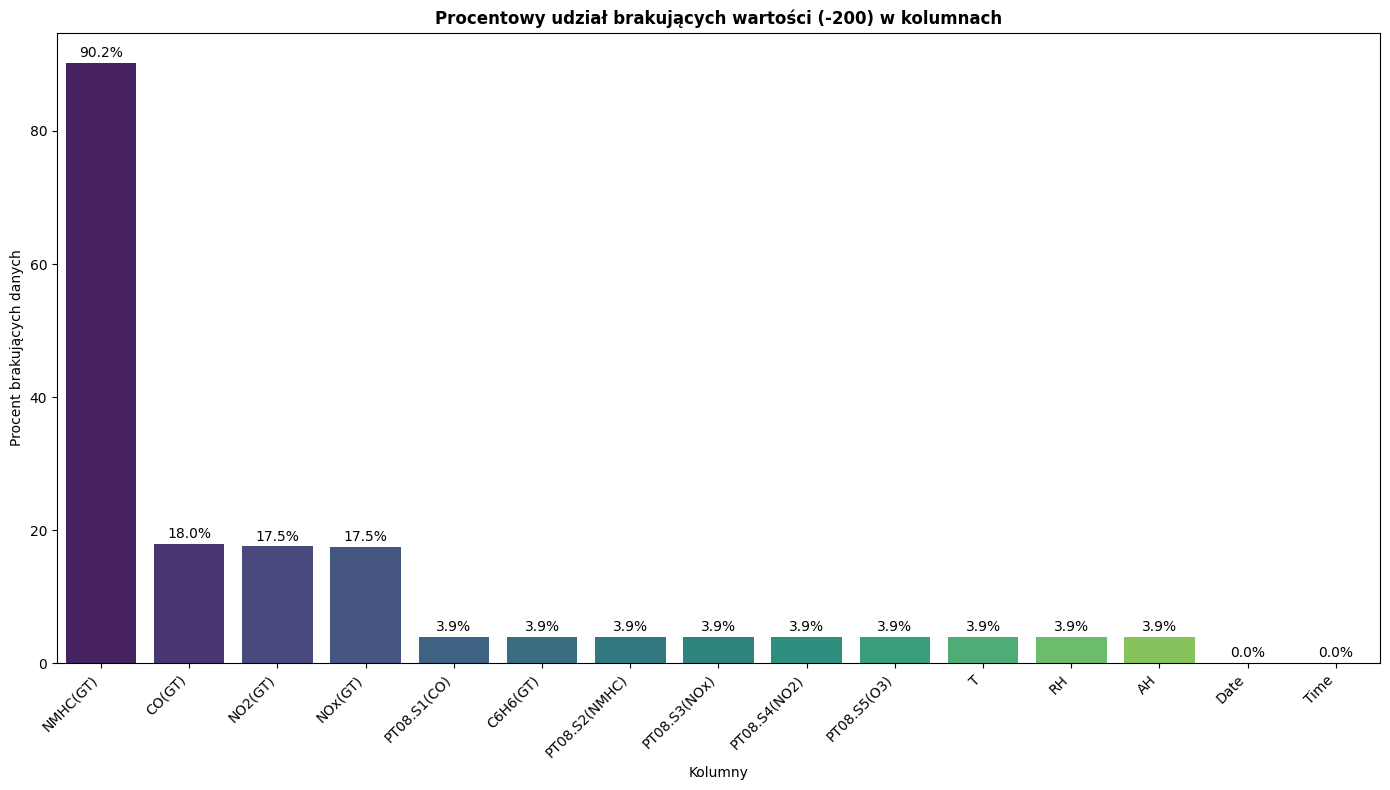

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

total_rows = len(data)
missing_counts = (data == -200).sum()
missing_percent = (missing_counts / total_rows) * 100

missing_data_df = pd.DataFrame({
    'Kolumna': missing_counts.index,
    'Liczba braków': missing_counts.values,
    'Procent braków': missing_percent.values
}).sort_values(by='Procent braków', ascending=False)

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=missing_data_df, 
    x='Kolumna', 
    y='Procent braków', 
    palette='viridis',
    hue='Kolumna'
)

plt.title('Procentowy udział brakujących wartości (-200) w kolumnach', fontweight='bold')
plt.ylabel('Procent brakujących danych')
plt.xlabel('Kolumny')
plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 7),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

### Wnioski z wykresu
Widać że NHMC(GT) jest brakujące w 90% wartościach - więc warto usunąć tą kolumnę.

In [3]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

data = data.drop(columns=['NMHC(GT)'])

# zmieńmy -200 na NaN - bo oznacza to samo w tym przypadku, a nie będzie się myliło jako wartość
data = data.replace(-200, np.nan)

# usuwamy czas - zostawiając miesiąc jako zmienną kategoryczną
data['Date'] = pd.to_datetime(data['Date'], format='mixed')
data['Month'] = data['Date'].dt.month.astype(str)
data = data.drop(columns=['Date', 'Time'])

# tworzymy nasz target z pozostałych kolumn (GT) - usuwając te wiersze gdzie są one puste - dzielimy na zbiór treningowy i testowy
# sumę GT liczymy przed skalowaniem żeby uniknąć utraty wiadomości o faktycznej wartości poszczególnych składników
target_columns = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
data = data.dropna(subset=target_columns, how='all')
data['GT'] = data[target_columns].sum(axis=1, skipna=True)
X = data.drop(columns=target_columns + ['GT'])
y = data['GT']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
numeric_features = X.columns.drop('Month').tolist()
categorical_features = ['Month']

# teraz możemy brakujące wartości np PT08.S1(CO) podstawić jako medianę
simp = SimpleImputer(missing_values=np.nan, strategy='median')
X_train[numeric_features] = simp.fit_transform(X_train[numeric_features])
X_test[numeric_features] = simp.transform(X_test[numeric_features])

# skalujemy aby wartości numeryczne były znormalizowane (od -1 do 1 ; średnia 0 ; odchylenie 1)
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

# miesiące one hot encodujemy - normalne inty by nie zadziałały bo nie rozumieją np że 1 i 12 ze sobą sąsiadują
enc = OneHotEncoder(sparse_output=False)
train_ohc_features = enc.fit_transform(X_train[categorical_features])
test_ohc_features = enc.transform(X_test[categorical_features])

ohc_cols = enc.get_feature_names_out(categorical_features)
train_ohc_df = pd.DataFrame(train_ohc_features, columns=ohc_cols, index=X_train.index)
test_ohc_df = pd.DataFrame(test_ohc_features, columns=ohc_cols, index=X_test.index)

X_train = X_train.drop(columns=['Month']).join(train_ohc_df)
X_test = X_test.drop(columns=['Month']).join(test_ohc_df)

In [5]:
print(X_train.shape, len(y_train))
print(X_test.shape, len(y_test))

(7460, 20) 7460
(1866, 20) 1866


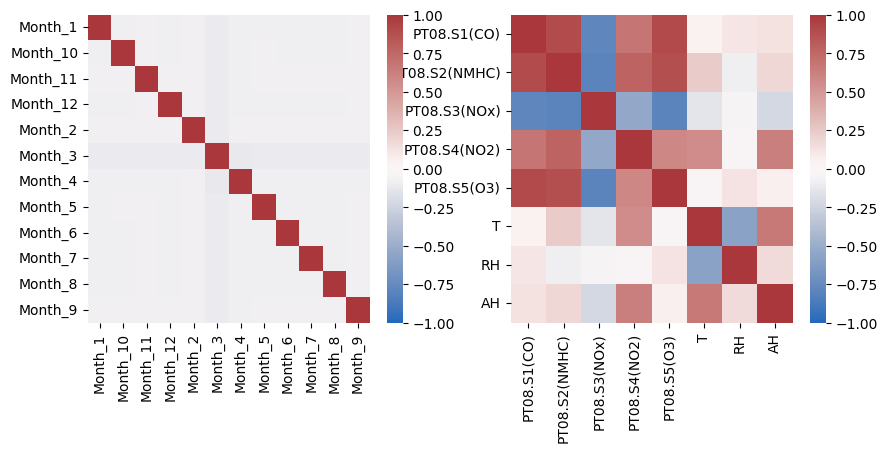

In [6]:
# (Nowe) zmienne tekstowe
corrs_txt = train_ohc_df.corr()
# Zmienne numeryczne
corrs_num = X_train.drop(columns=train_ohc_df.columns).corr()

kwargs = {'cmap': 'vlag', 'vmin': -1, 'vmax': 1}
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(corrs_txt, ax=ax[0], **kwargs)
sns.heatmap(corrs_num, ax=ax[1], **kwargs)
plt.show()

In [7]:
def remove_highly_correlated_features(df, threshold=0.8):
    """
    Usuwa cechy o korelacji >= threshold, zachowując tę o wyższej wariancji

    Parametry:
        df (pd.DataFrame): dane wejściowe
        threshold (float): próg korelacji do usunięcia

    Zwraca:
        list: kolumny które należy dropnąć, aby pozbyć się wysokiej koleracji
    """
    # Oblicz macierz korelacji i jej górny trójkąt
    corr_matrix = df.corr()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    # Identyfikacja cech do usunięcia
    to_drop = {
        column if df[column].var() < df[feature].var() else feature
        for column in upper_tri.columns
        for feature in upper_tri.index[upper_tri[column] >= threshold]
    }
    return list(to_drop)

In [8]:
to_drop = remove_highly_correlated_features(X_train)
X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)

In [9]:
print(to_drop)

['PT08.S5(O3)', 'PT08.S1(CO)']


Usuwamy powyższe kolumny jeszcze, bo są silnie skorelowane z innymi.

## Trening modeli

In [10]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, HuberRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr

# domyślne parametry
models = {
    'Liniowy': LinearRegression(),
    'Lasso (L1)': Lasso(random_state=42),
    'Ridge (L2)': Ridge(random_state=42),
    'Regresja Hubera': HuberRegressor()
}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    correlation = pearsonr(y_pred, y_test)[0]

    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'Korelacja': correlation
    })

# wyświetlenie wyników błedów poszczególnych modeli
results_df = pd.DataFrame(results)
print(results_df)

             Model        RMSE         MAE  Korelacja
0          Liniowy  157.499001  105.505862   0.819701
1       Lasso (L1)  157.682832  103.346248   0.820637
2       Ridge (L2)  157.495748  105.469848   0.819733
3  Regresja Hubera  158.077394  100.181999   0.819260


In [11]:
import time
from sklearn.model_selection import GridSearchCV

param_grid = {
    'Liniowy': {},
    'Lasso (L1)': {'alpha': [0.01, 0.1, 1.0, 10.0, 50.0]},
    'Ridge (L2)': {'alpha': [0.1, 1.0, 10.0, 100.0, 500.0]},
    'Regresja Hubera': {'epsilon': [1.1, 1.35, 1.5, 1.75, 2.0, 2.25, 2.5], 'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]}
}

def grid_search_model(X_train, y_train, X_test, y_test):
    results = []
    best_params = {}

    for name, model in models.items():
        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grid[name],
            scoring='neg_mean_squared_error',
            cv=5,
            n_jobs=-1
        )
        
        start_time = time.time()

        grid.fit(X_train, y_train)

        train_time = time.time() - start_time

        best_model = grid.best_estimator_
        best_params[name] = best_model

        y_pred = best_model.predict(X_test)
        
        rmse = root_mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        correlation = pearsonr(y_pred, y_test)[0]

        results.append({
            'Model': name,
            'Najlepsze Parametry': grid.best_params_,
            'RMSE': round(rmse, 2),
            'MAE': round(mae, 2),
            'Korelacja': correlation,
            'Czas Treningu [s]': round(train_time, 4)
        })

    results_df = pd.DataFrame(results)
    print(results_df)

grid_search_model(X_train, y_train, X_test, y_test)

             Model             Najlepsze Parametry    RMSE     MAE  Korelacja  \
0          Liniowy                              {}  157.50  105.51   0.819701   
1       Lasso (L1)                  {'alpha': 0.1}  157.43  105.18   0.820000   
2       Ridge (L2)                  {'alpha': 1.0}  157.50  105.47   0.819733   
3  Regresja Hubera  {'alpha': 0.1, 'epsilon': 2.5}  156.46  102.72   0.822156   

   Czas Treningu [s]  
0             2.4457  
1             2.0659  
2             0.1364  
3             4.9379  


### Wnioski
Finalnie najlepszym modelem okazała się `Regresa Hubera` osiągając najmniejszy wynik dla zaskakująco wysokiego epsilona (podczas testów zauważyłem, że jeszcze wyższy epsilon był zawsze wybierany jako najlepszy, ale skutkował słabszym wynikiem - co było pewnie spowodowane overfittingiem).

Liniowa regresja, Lasso i Ridge mają bardzo zbliżony (czasem nawet ideantyczny) wynik. Dzieje się tak z powodu dobrze wykonanego preprocessingu, którym pozbyłem się problemów, które taki Ridge rozwiązuje.

Jeśli chodzi o czas treningu to widać znacząco dłuższy czas dla Regresji Hubera w porównaniu z resztą - prawdopodobnie dlatego, że ma 2 parameetry do przetestowania zamiast 1 (lub 0).

Wynik korelacji Pearsona około **0.82** to bardzo dobry wynik. Świadczy o tym, że modele dobrze podążają za prawdziwym trendem w `y_test`.

## Wpływ przetwarzania danych na wynik

In [12]:
# tworzymy oryginalne dane na nowo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train)

      PT08.S1(CO)  PT08.S2(NMHC)  PT08.S3(NOx)  PT08.S4(NO2)  PT08.S5(O3)  \
3945        882.0          767.0         856.0        1492.0        897.0   
7665        881.0          578.0        1017.0         876.0        607.0   
2421          NaN            NaN           NaN           NaN          NaN   
1042        844.0          608.0        1213.0        1314.0        803.0   
611        1024.0          658.0        1175.0        1417.0        682.0   
...           ...            ...           ...           ...          ...   
5765       1050.0          881.0         732.0        1363.0        982.0   
5222       1097.0         1103.0         659.0        1520.0       1113.0   
5421       1476.0         1352.0         474.0        1996.0       1568.0   
860        1418.0         1282.0         681.0        1890.0       1418.0   
7301       1102.0          813.0         764.0        1204.0       1000.0   

         T    RH      AH Month  
3945  20.5  60.6  1.4470     8  
7665   5.

Wcześniej na tych danych zrobiliśmy następujące kroki:
 - użyliśmy `SimpleImputer` z medianą (zamiast tego możemy usunąć wiersze z pustymi danymi)
 - użyliśmy `StandardScaler`
 - na miesiącach zrobiliśmy `One Hot Encoding`
 - usunęliśmy silnie skorelowane kolumny

In [13]:
print(X_train.dtypes)

PT08.S1(CO)      float64
PT08.S2(NMHC)    float64
PT08.S3(NOx)     float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
Month                str
dtype: object


In [14]:
import itertools
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# różne możliwości
scaler_opts = [True, False]
month_enc_opts = [True, False]
correlation_deletion_opts = [True, False]
median_imputer_opts = [True, False]

combinations = list(itertools.product(scaler_opts, month_enc_opts, correlation_deletion_opts, median_imputer_opts))

# mimo że są to liczby 1-12 to są w formie stringa a nie inta/floata
X_train['Month'] = X_train['Month'].astype(float)
X_test['Month'] = X_test['Month'].astype(float)

for use_scaler, use_month_enc, use_corr_del, use_imputer in combinations:
    
    # skopiowanie danych dla każdego przypadku
    X_train_copy = X_train.copy()
    X_test_copy = X_test.copy()
    y_train_copy = y_train.copy()
    y_test_copy = y_test.copy()

    numeric_features = X.columns.drop('Month').tolist()
    categorical_features = ['Month']
    
    # nazwa żeby móc dobrze porównać wyniki
    name_parts = []
    if use_scaler: name_parts.append('Scaler')
    if use_month_enc: name_parts.append('Month OHE')
    if use_corr_del: name_parts.append('No Corr')
    if use_imputer: name_parts.append('Imputer')
    name = " + ".join(name_parts) if name_parts else "Brak preprocessingu"
    
    # usuwamy NaN gdy brak imputera
    if not use_imputer:
        X_train_copy = X_train_copy.dropna()
        X_test_copy = X_test_copy.dropna()
        y_train_copy = y_train_copy.loc[X_train_copy.index]
        y_test_copy = y_test_copy.loc[X_test_copy.index]

    # usuwamy skorelowane dane
    if use_corr_del:
        to_drop = remove_highly_correlated_features(X_train_copy)
        X_train_copy = X_train_copy.drop(columns=to_drop)
        X_test_copy = X_test_copy.drop(columns=to_drop)
        
        numeric_features = [col for col in numeric_features if col not in to_drop]

    # jeśli nie enkodujemy miesięcy to dodajemy je do numerycznych
    if not use_month_enc:
        numeric_features.append('Month')
        categorical_features = []
        
    num_steps = []
    if use_imputer:
        num_steps.append(('imputer', SimpleImputer(strategy='median')))
    if use_scaler:
        num_steps.append(('scaler', StandardScaler()))
        
    # zabezpieczenie dla sytuacji kiedy steps=[] , bez tego jest błąd 
    if not num_steps:
        num_steps.append(('passthrough', 'passthrough'))
        
    num_pipe = Pipeline(steps=num_steps)
    transformers = [('num_pipe', num_pipe, numeric_features)]
    
    # dodajemy pipe dla kategorycznych jeśli musimy zmienić miesiące
    if use_month_enc:
        cat_pipe = Pipeline(steps=[('onehot', OneHotEncoder(sparse_output=False))])
        transformers.append(('cat_pipe', cat_pipe, categorical_features))

    preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')
    preprocessor.set_output(transform="pandas")

    X_train_final = preprocessor.fit_transform(X_train_copy)
    X_test_final = preprocessor.transform(X_test_copy)

    print(f"========  {name} ========")
    grid_search_model(X_train_final, y_train_copy, X_test_final, y_test_copy)
    print("\n")

========  Scaler + Month OHE + No Corr + Imputer ========


C:\Users\piotr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.278e+04, tolerance: 5.482e+04
  model = cd_fast.enet_coordinate_descent(


             Model                Najlepsze Parametry    RMSE     MAE  \
0          Liniowy                                 {}  165.65  115.96   
1       Lasso (L1)                    {'alpha': 0.01}  165.65  115.94   
2       Ridge (L2)                     {'alpha': 1.0}  165.64  115.92   
3  Regresja Hubera  {'alpha': 0.0001, 'epsilon': 2.5}  165.43  115.41   

   Korelacja  Czas Treningu [s]  
0   0.797947             0.0281  
1   0.797974             0.1459  
2   0.797989             0.0817  
3   0.798663             4.0887  


========  Scaler + Month OHE + No Corr ========
             Model                Najlepsze Parametry    RMSE     MAE  \
0          Liniowy                                 {}  159.58  112.93   
1       Lasso (L1)                    {'alpha': 0.01}  159.58  112.92   
2       Ridge (L2)                     {'alpha': 1.0}  159.58  112.92   
3  Regresja Hubera  {'alpha': 0.0001, 'epsilon': 2.5}  159.45  112.67   

   Korelacja  Czas Treningu [s]  
0   0.810710  

C:\Users\piotr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.796e+07, tolerance: 5.482e+04
  model = cd_fast.enet_coordinate_descent(
C:\Users\piotr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, sel

             Model              Najlepsze Parametry    RMSE     MAE  \
0          Liniowy                               {}  165.65  115.96   
1       Lasso (L1)                  {'alpha': 0.01}  165.65  115.94   
2       Ridge (L2)                   {'alpha': 1.0}  165.65  115.93   
3  Regresja Hubera  {'alpha': 0.01, 'epsilon': 1.1}  168.30  116.80   

   Korelacja  Czas Treningu [s]  
0   0.797947             0.0259  
1   0.797968             0.1524  
2   0.797980             0.0923  
3   0.792755             6.9515  


========  Month OHE + No Corr ========


...

C:\Users\piotr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


             Model               Najlepsze Parametry    RMSE     MAE  \
0          Liniowy                                {}  168.76  119.28   
1       Lasso (L1)                   {'alpha': 0.01}  168.76  119.28   
2       Ridge (L2)                    {'alpha': 1.0}  168.77  119.28   
3  Regresja Hubera  {'alpha': 0.001, 'epsilon': 2.5}  173.28  126.60   

   Korelacja  Czas Treningu [s]  
0   0.785584             0.0259  
1   0.785572             0.0630  
2   0.785560             0.0489  
3   0.771392             2.1208  


========  Imputer ========


C:\Users\piotr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


             Model             Najlepsze Parametry    RMSE     MAE  Korelacja  \
0          Liniowy                              {}  164.51  104.75   0.801814   
1       Lasso (L1)                  {'alpha': 1.0}  164.49  104.84   0.801903   
2       Ridge (L2)                {'alpha': 500.0}  164.49  104.80   0.801893   
3  Regresja Hubera  {'alpha': 0.1, 'epsilon': 1.1}  167.05  103.81   0.797440   

   Czas Treningu [s]  
0             0.0260  
1             0.0623  
2             0.0587  
3             2.5839  


========  Brak preprocessingu ========
             Model               Najlepsze Parametry    RMSE     MAE  \
0          Liniowy                                {}  154.13  101.45   
1       Lasso (L1)                   {'alpha': 0.01}  154.13  101.45   
2       Ridge (L2)                   {'alpha': 10.0}  154.10  101.44   
3  Regresja Hubera  {'alpha': 0.001, 'epsilon': 2.5}  159.35  105.68   

   Korelacja  Czas Treningu [s]  
0   0.825224             0.0257  
1   0.825

C:\Users\piotr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


### Wnioski

Nie możemy się kierować `RMSE` i `MAE`, bo w niektórych sytuacjach po usunięciu kolumn mamy mniej kolumn, więc błąd jest mniejszy.

Najlepszą `Korelację` mamy dla `Scaler + Month OHE` prawdopodobnie jest to spowodowane tym, że:
 - `Inputer` wprowadza trochę nieprawdziwych informacji i szum przez co psuje jakość modelu
 - `No Corr` usuwa wysoko skorelowane kolumny, ale najwyraźniej niosące jakieś ważne informacje dla modelu

Bez `Scalera` widzimy błąd `STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT`, prawdopodobnie w Regresji Hubera. Widzimy bez niego również duży wzrost błędów w większości przypadków. Widać, że skalowanie jest bardzo ważne.

Zauważyć można również spadek `Korelacji` w przypadkach bez `Month OHE`. Dzięki enkodowaniu model "rozumie" sezonowość dużo lepiej i nie uważa miesiąca tylko jako liczbę.

## Wizualizacja wartości parametrów modeli
Użyjemy teraz najlepszego preprocessingu: `Scaler + Month OHE`

In [15]:
numeric_features = X.columns.drop('Month').tolist()
categorical_features = ['Month']

X_train = X_train.dropna()
X_test = X_test.dropna()
y_train = y_train.loc[X_train.index]
y_test = y_test.loc[X_test.index]


num_pipe = Pipeline(steps=[('scaler', StandardScaler())])
cat_pipe = Pipeline(steps=[('onehot', OneHotEncoder(sparse_output=False))])
transformers = [('num_pipe', num_pipe, numeric_features), ('cat_pipe', cat_pipe, categorical_features)]

preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')
preprocessor.set_output(transform="pandas")

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

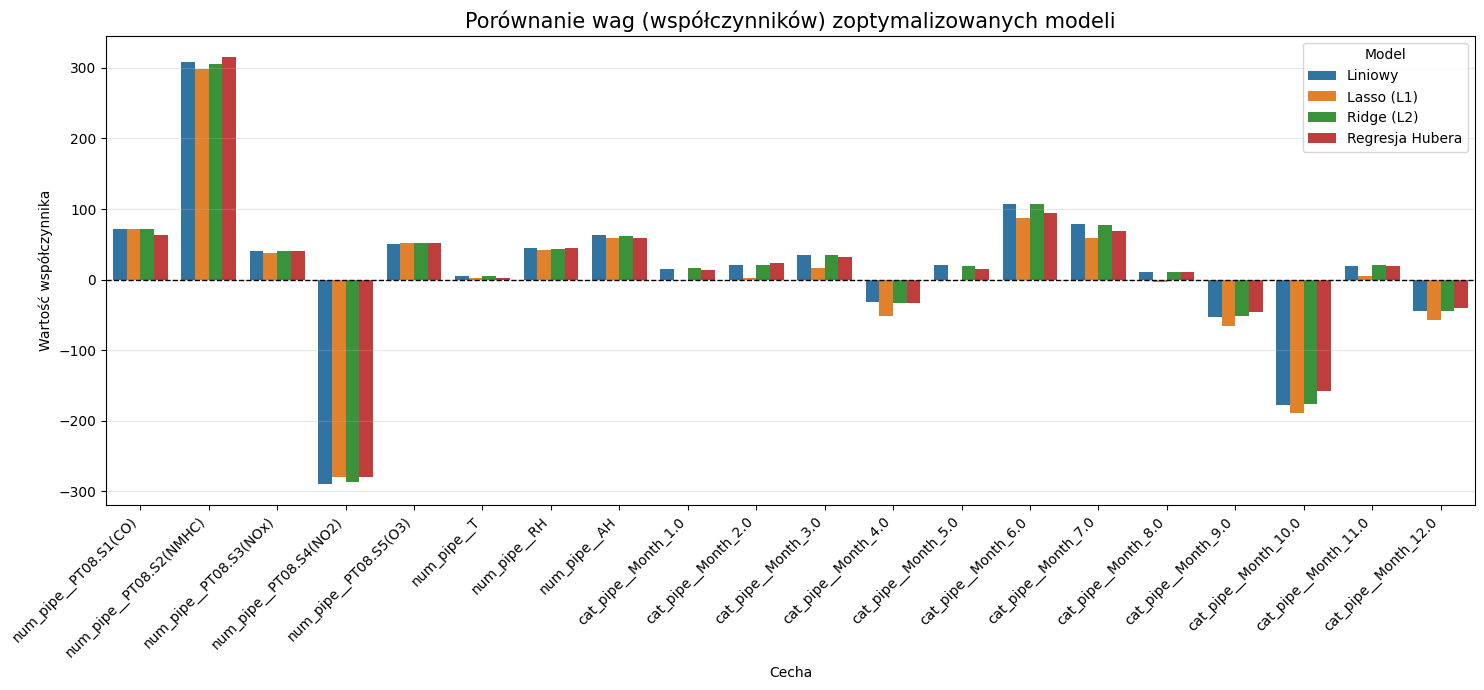

In [16]:
# parametry wzięte z wyniku poprzedniego zadania
final_models = {
    'Liniowy': LinearRegression(),
    'Lasso (L1)': Lasso(alpha=0.1),
    'Ridge (L2)': Ridge(alpha=1.0),
    'Regresja Hubera': HuberRegressor(alpha=0.1, epsilon=2.5)
}

# nazwy kolumn wyciągamy z X_train już po preprocessingu
feature_names = X_train.columns.tolist()
coef_data = []

# fitujemy każdy z powyższych modeli i wyciągamu wagi za pomocą coef_
for name, model in final_models.items():
    model.fit(X_train, y_train)
    weights = model.coef_.flatten()
    
    for feat, weight in zip(feature_names, weights):
        coef_data.append({'Cecha': feat, 'Waga': weight, 'Model': name})

df_coef = pd.DataFrame(coef_data)

# rysujemy wykres
plt.figure(figsize=(15, 7))
sns.barplot(data=df_coef, x='Cecha', y='Waga', hue='Model')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Porównanie wag (współczynników) zoptymalizowanych modeli", fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Wartość współczynnika")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Wnioski
Widać różnorodne wagi dla poszczególnych miesięcy (nie liniową zależność), co pokazuje, że faktycznie OHE jest kluczowe.

Zauważamy również prawie zerową wartość współczynnika temperatury (nie wnosi za dużo do modelu).

Największe znaczenie mają `PT08.S2(NMHC)` oraz `PT08.S4(NO2)`, które się ze sobą prawdopodobnie przeciwważą - mierzą skorelowane zjawiska i popełniają te same lub podobne błędy, więc model drastycznie zawyża odczyt jednego z nich i koryguje go odczytem z drugiego.

# Zadanie dodatkowe [0-3] pkt

Użyj modelu liniowych efektów mieszanych w zadaniu wyżej:
1. Wykorzystaj API ze [statsmodels](https://www.statsmodels.org/stable/mixed_linear.html)
1. Użyj miesiąca jako zmiennej modelującej efekt losowy (potencjalny *bias*)
1. Skomentuj wyniki w porównaniu do zadania wyżej (miesiąc jako zmienna kategoryczna)